In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("superstore.csv")

In [23]:
sns.set(style="whitegrid")

In [24]:
df.columns = df.columns.str.strip()  # Remove spaces
print("Columns after cleaning:", df.columns.tolist())

Columns after cleaning: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


In [25]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

In [27]:
print("Missing values:\n", df.isnull().sum())
df = df.dropna(subset=['Postal Code'])
df.shape

Missing values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64


(9789, 18)

In [29]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Sales:\n", top_products)



Top 10 Products by Sales:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


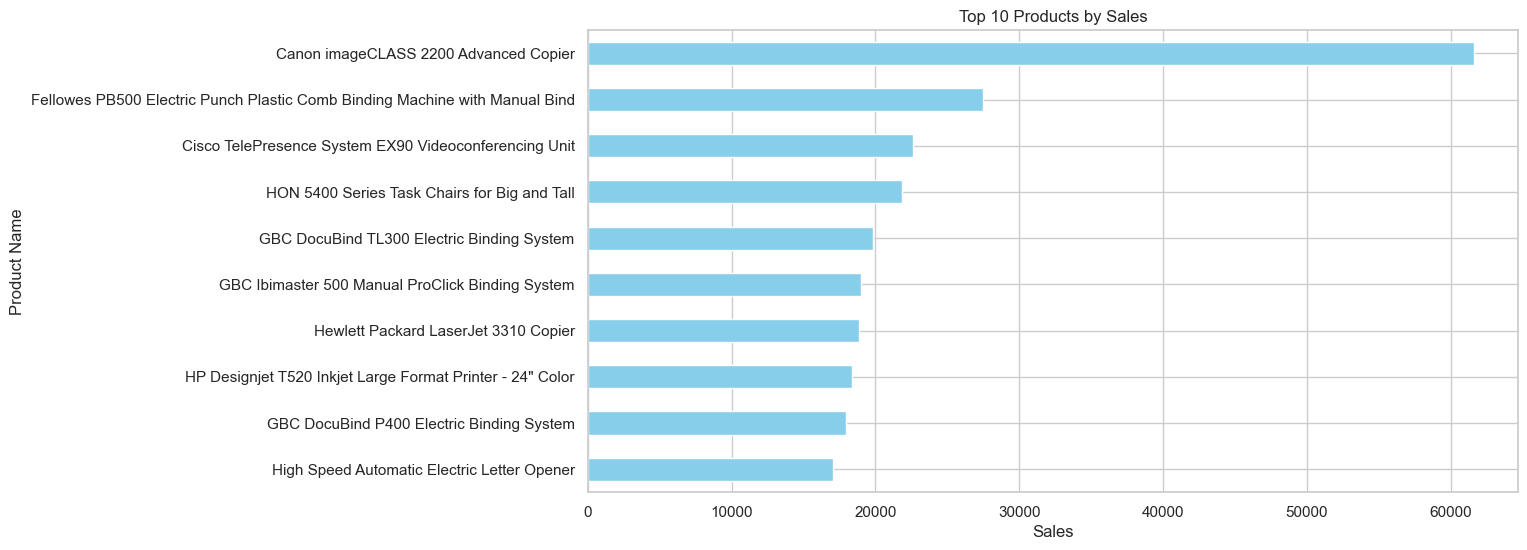

In [30]:
plt.figure(figsize=(12,6))
top_products.plot(kind='barh', color='skyblue')
plt.xlabel("Sales")
plt.title("Top 10 Products by Sales")
plt.gca().invert_yaxis()  # Highest at top
plt.show()

In [31]:
sales_region = df.groupby('Region')['Sales'].sum()
print("\nSales by Region:\n", sales_region)


Sales by Region:
 Region
Central    492646.9132
East       660589.3560
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


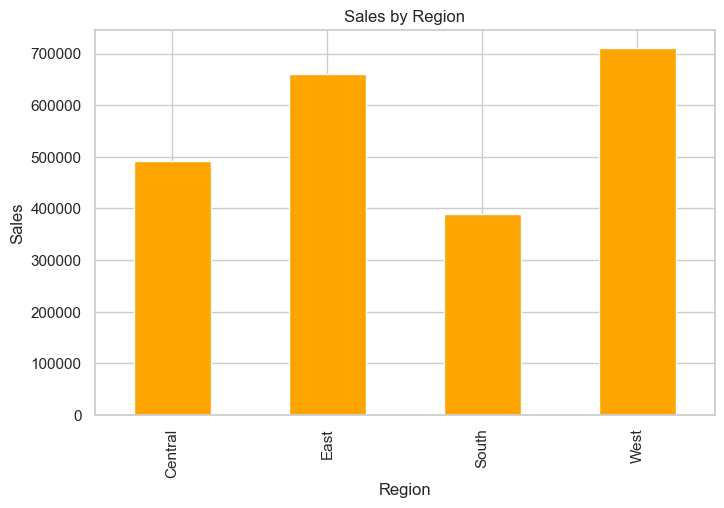

In [32]:
plt.figure(figsize=(8,5))
sales_region.plot(kind='bar', color='orange')
plt.ylabel("Sales")
plt.title("Sales by Region")
plt.show()

In [33]:
sales_category = df.groupby('Category')['Sales'].sum()
print("\nSales by Category:\n", sales_category)


Sales by Category:
 Category
Furniture          723538.4757
Office Supplies    703212.8240
Technology         825856.1130
Name: Sales, dtype: float64


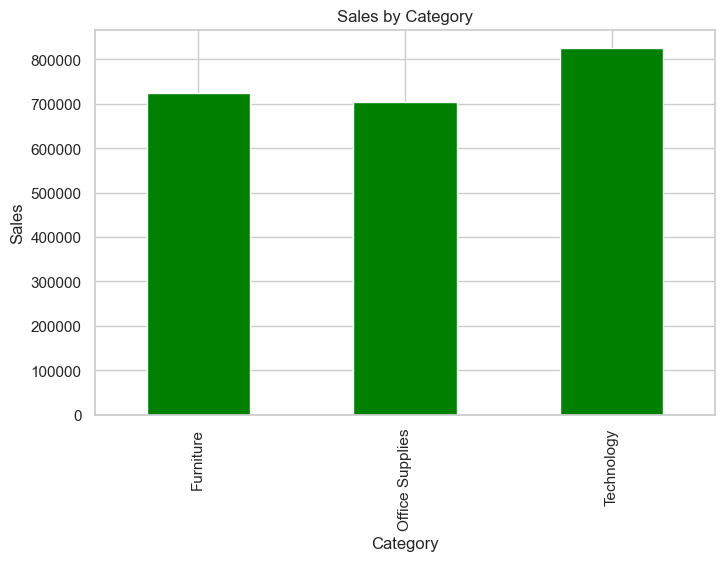

In [34]:
plt.figure(figsize=(8,5))
sales_category.plot(kind='bar', color='green')
plt.ylabel("Sales")
plt.title("Sales by Category")
plt.show()


In [35]:
df['Month_Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month_Year')['Sales'].sum()

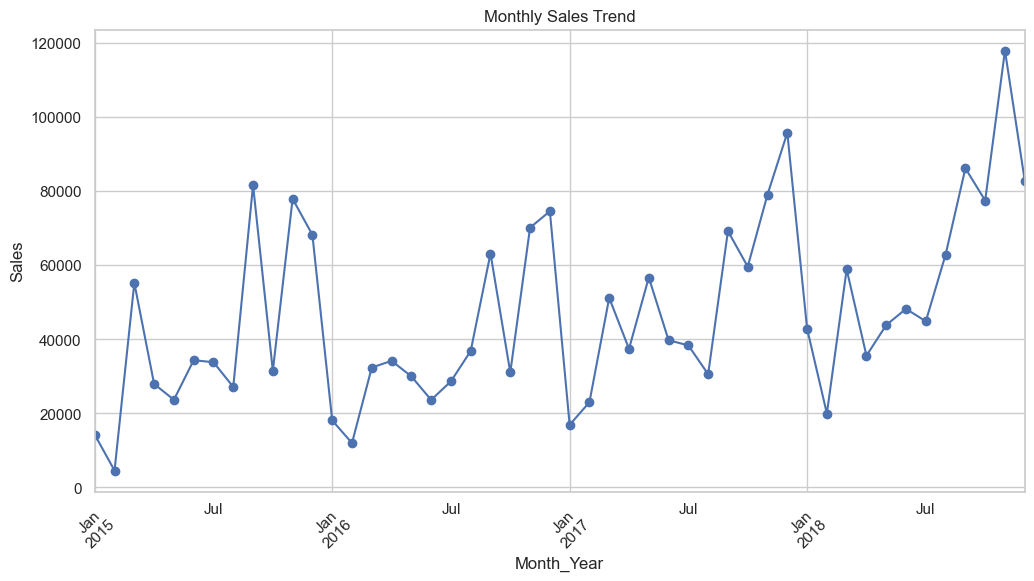

In [36]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

In [37]:
segment_sales = df.groupby('Segment')['Sales'].sum()
print("\nSales by Segment:\n", segment_sales)


Sales by Segment:
 Segment
Consumer       1.146708e+06
Corporate      6.822118e+05
Home Office    4.236874e+05
Name: Sales, dtype: float64


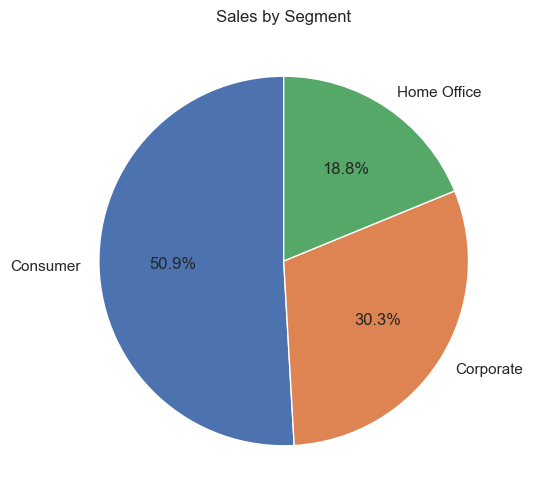

In [38]:

plt.figure(figsize=(6,6))
segment_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Sales by Segment")
plt.ylabel("")  # Hide y-label for pie chart
plt.show()

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu